В цьому домашньому завданні ми з вами побудуємо повноцінне ML-рішення реальної ML-задачі. Ви вже маєте всі знання, які для цього потрібні. Дотримуйтесь інструкцій, та користуйтесь матеріалами лекцій, аби виконувати завдання. Тут інструкції будуть детальні, а в подільших завданнях - будуть ставати все менш детальними, аби ви вже починали самостійно структурувати ML-проєкт і до кінця курсу для вас розвʼязати будь-яку ML–задачу було eazy-breezy.

## Dataset

Будемо працювати з набором даних `cars.csv`, який описує автомобілі і їх ціну у індійських рупіях :) Мета - передбачити ціну авто за його характеристиками. Опис набору даних:

| Назва рядка            | Опис                                                                                                                                                 |
|------------------------|--------------------------------------------------------------------------------------------------------------------------------------------------------|
| Car_ID                 | Унікальний ідентифікатор для кожного оголошення про автомобіль.                                                                                         |
| Brand                  | Бренд або виробник автомобіля (наприклад, Toyota, Honda, Ford тощо).                                                                                     |
| Model                  | Модель автомобіля (наприклад, Camry, Civic, Mustang тощо).                                                                                               |
| Year                   | Рік виготовлення автомобіля.                                                                                                                            |
| Kilometers_Driven      | Загальний пробіг автомобіля у кілометрах.                                                                                                               |
| Fuel_Type              | Тип палива, який використовує автомобіль (наприклад, бензин, дизель, електро тощо).                                                                      |
| Transmission           | Тип трансмісії автомобіля (наприклад, механічна, автоматична).                                                                                           |
| Owner_Type             | Кількість попередніх власників автомобіля (наприклад, перший, другий, третій).                                                                           |
| Mileage                | Паливна ефективність автомобіля у кілометрах на літр.                                                                                                   |
| Engine                 | Об'єм двигуна автомобіля в кубічних сантиметрах (CC).                                                                                                   |
| Power                  | Максимальна потужність автомобіля в кінських силах (bhp).                                                                                               |
| Seats                  | Кількість місць в автомобілі.                                                                                                                           |
| Price                  | Вартість автомобіля в INR (індійські рупії), що є цільовою змінною для прогнозування.                                                                   |

# Імпорти

Для зручності рекомендую всі імпорти розмістити тут нагорі, аби коли ви перезавантажували ноутбук, одразу можна було в один запуск клітинки імпортувати всі потрібні бібліотеки.

In [88]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler

import statsmodels.api as sm

from google.colab import drive

# Знайомство з даними

**Завдання 1.** Завантажте набір даних `cars.csv` в pandas.DataFrame. Виведіть перші 5 записів.

In [39]:
drive.mount('/content/drive', force_remount = True)
cars_df = pd.read_csv("drive/MyDrive/Colab Notebooks/data/cars.csv")
cars_df.head()

Mounted at /content/drive


,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price
0,1,Toyota,Corolla,2018,50000,Petrol,Manual,First,15,1498,108,5,800000
1,2,Honda,Civic,2019,40000,Petrol,Automatic,Second,17,1597,140,5,1000000
2,3,Ford,Mustang,2017,20000,Petrol,Automatic,First,10,4951,395,4,2500000
3,4,Maruti,Swift,2020,30000,Diesel,Manual,Third,23,1248,74,5,600000
4,5,Hyundai,Sonata,2016,60000,Diesel,Automatic,Second,18,1999,194,5,850000


**Завдання 2.** Виведіть типи даних колонок даних, а також дослідіть, які по факту типи даних мають записи в кожній колонці (тип `object` може містити різні типи даних) і скільки значень є в кожній категоріальній колонці.

Напишіть висновок, скільки в наборі даних числових та категоріальних колонок кожного з трьох різних типів (бінарна, мільтикатегоріальна без порядку, мультикатегоріальна з порядком). Шаблон висновку

```
В наборі даних 10 числових і 10 категоріальних колонок з них
- 2 бінарні (мають лише 2 значення)
- 6 мультикатегоріальних (більше 2х значень) зі значеннями, для яких немає відношення порядку
- 2 колонки, в яких можна встановити відношення порядку (наприклад Small<Medium<Large)
```

Якщо не знаєте, як це зробити з `pandas` - ось підказка, які методи можуть допомогти вам виконати це завдання

- pandas.DataFrame.info()
- pandas.DataFrame.dtypes
- pandas.DataFrame.loc[...]
- pandas.DataFrame.select_dtypes(...)
- pandas.Series.unique()
- pandas.Series.nunique()

Детальніше ознайомитись з кожним ви можете в [документації](https://pandas.pydata.org/docs/reference/frame.html), або написати в окремій клітинці знак питання і назву методу (тільки приберіть це перед здачею, бо перегляд документації - не допомагає зрозуміти дані і хід думок, а Ваша робота - це як презентація замовнику зробленої задачі).


In [ ]:
# приклад як викликати документацію, якщо у Вас pandas імпортований як pd
?pd.DataFrame.info

In [40]:
cars_df.shape

(100, 13)

In [41]:
cars_df.dtypes

,0
Car_ID,int64
Brand,object
Model,object
Year,int64
Kilometers_Driven,int64
Fuel_Type,object
Transmission,object
Owner_Type,object
Mileage,int64
Engine,int64


In [42]:
cars_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Car_ID             100 non-null    int64 
 1   Brand              100 non-null    object
 2   Model              100 non-null    object
 3   Year               100 non-null    int64 
 4   Kilometers_Driven  100 non-null    int64 
 5   Fuel_Type          100 non-null    object
 6   Transmission       100 non-null    object
 7   Owner_Type         100 non-null    object
 8   Mileage            100 non-null    int64 
 9   Engine             100 non-null    int64 
 10  Power              100 non-null    int64 
 11  Seats              100 non-null    int64 
 12  Price              100 non-null    int64 
dtypes: int64(8), object(5)
memory usage: 10.3+ KB


In [43]:
cars_df.select_dtypes(include = "object").columns

Index(['Brand', 'Model', 'Fuel_Type', 'Transmission', 'Owner_Type'], dtype='object')

In [44]:
print(f"{'Колонка':<15} | {'Кількість unique':<15} | {'Значення'}")
print("-" * 80)

for x in cars_df.select_dtypes(include = "object").columns:
  print(f'{x:<15} | {cars_df[x].nunique():<15} | {cars_df[x].unique()}')
  print("-" * 80)

Колонка         | Кількість unique | Значення
--------------------------------------------------------------------------------
Brand           | 11              | ['Toyota' 'Honda' 'Ford' 'Maruti' 'Hyundai' 'Tata' 'Mahindra' 'Volkswagen'
 'Audi' 'BMW' 'Mercedes']
--------------------------------------------------------------------------------
Model           | 58              | ['Corolla' 'Civic' 'Mustang' 'Swift' 'Sonata' 'Nexon' 'Scorpio' 'Polo'
 'A4' 'X1' 'C-Class' 'Endeavour' 'Creta' 'Harrier' 'Ertiga' 'City'
 'Tiguan' 'Q3' '5 Series' 'GLC' 'Innova' 'Figo' 'Verna' 'Altroz' 'Thar'
 'Passat' 'A6' 'X3' 'E-Class' 'Fortuner' 'Aspire' 'Elantra' 'Safari'
 'Vitara' 'WR-V' 'Ameo' 'A3' '7 Series' 'GLE' 'Yaris' 'Ranger' 'Santro'
 'Tigor' 'S-Cross' 'BR-V' 'T-Roc' 'Q7' 'X5' 'GLA' 'Camry' 'Venue' 'Tiago'
 'XUV300' 'Vento' 'A5' '3 Series' 'Innova Crysta' 'EcoSport']
--------------------------------------------------------------------------------
Fuel_Type       | 2               | ['Petrol' 'Dies

In [45]:
cars_df.describe()

,Car_ID,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,Price
count,100.000000,100.00000,100.000000,100.000000,100.000000,100.000000,100.000000,1.000000e+02
mean,50.500000,2018.39000,28150.000000,17.210000,1855.230000,158.130000,5.230000,1.574000e+06
std,29.011492,1.17116,9121.375716,3.309902,631.311475,76.968137,0.750151,1.000265e+06
min,1.000000,2016.00000,10000.000000,10.000000,999.000000,68.000000,4.000000,4.500000e+05
25%,25.750000,2017.75000,22000.000000,15.000000,1462.000000,103.000000,5.000000,7.000000e+05
50%,50.500000,2018.00000,27000.000000,17.000000,1774.000000,148.000000,5.000000,1.300000e+06
75%,75.250000,2019.00000,32000.000000,19.000000,2143.000000,187.000000,5.000000,2.500000e+06
max,100.000000,2021.00000,60000.000000,25.000000,4951.000000,396.000000,7.000000,4.000000e+06


В наборі даних 8 числових і 5 категоріальних колонок. З них:  

- 2 бінарні (мають лише 2 значення: Fuel_Type і Transmission)
- 3 мультикатегоріальних (більше 2х значень) зі значеннями, для яких немає відношення порядку
- 1 колонка, в яких можна встановити відношення порядку (Owner_Type: ['First', 'Second', 'Third'])

**Завдання 3**. Розділіть дані на тренувальні і тест. Відведіть в тест 20%, поставте `random_state=12`. Ми будемо передбачати колонку `Price` - тож, вона є цільовою змінною. В результаті у Вас має бути 4 набори даних `X_train, X_test, y_train, y_test`.

Надалі ми всюди тренуємо методи для кодування, масштабування та саму модель тільки на тренувальних даних X_train (та y_train для моделі), а на тестувальних лише використовуємо вже навчені методи для кодування, масштабування і модель викликаючи в них `transform()` (для методів обробки даних) або `predict()` (для моделі).

І так само треба робити завжди.

In [46]:
X = cars_df.drop(columns=['Price'])
y = cars_df['Price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=12)

**Завдання 4**. Кодуємо категоріальні колонки.

1. Закодуйте колонки з бінарними значеннями `Fuel_Type` і `Transmission` так, аби вони були у чисельному представленні і містили лише 0 так 1. Приклад був у лекції. Значення 1 нехай буде у категорії, яка містить більше значень в колонці.

2. Закодуйте колонку `Brand` з використанням `sklearn.preprocessing.OneHotEncoder` аналогічно до того, як ми робили це в лекції. Увага! Ми робимо виклик методу `Encoder.fit()` на тренувальних даних `X_train`, а на тестувальних тільки викликаємо `Encoder.transform()`. Додайте закодовані значення в набори даних `X_train`, `X_test`.

3. Колонку `Owner_Type` з використанням `sklearn.preprocessing.OrdinalEncoder` я закодую для вас. Проаналізуйте, що відбувається.

Колонка `Model` містять забагато значень для кодування в тому вигляді, як вона є зараз, з огляду на невелику кількість даних. Якщо ви бачите, як можна згрупувати значення в цій колонці скоротивши кількість унікальних значень до 3-5, то можете виконати ще цю трансформацію, використати цю колонку в моделі і отримати додаткову практику і бал, якщо все буде зроблено правильно. А якщо неправильно - то фідбек на Вашу роботу :)

In [47]:
#Кодування бінарних значень
cars_df['Fuel_Type'].value_counts()

,count
Fuel_Type,
Petrol,52
Diesel,48


In [48]:
cars_df['Transmission'].value_counts()

,count
Transmission,
Automatic,57
Manual,43


In [49]:
fuel_type_codes = {'Diesel': 0, 'Petrol': 1}
X_train['Fuel_Type_Code'] = X_train['Fuel_Type'].map(fuel_type_codes)
X_test['Fuel_Type_Code'] = X_test['Fuel_Type'].map(fuel_type_codes)

transmission_codes = {'Manual': 0, 'Automatic': 1}
X_train['Transmission_Code'] = X_train['Transmission'].map(transmission_codes)
X_test['Transmission_Code'] = X_test['Transmission'].map(transmission_codes)

In [50]:
#колонка Brand
enc = preprocessing.OneHotEncoder(sparse_output=False)
enc.fit(X_train[['Brand']])
enc.categories_

[array(['Audi', 'BMW', 'Ford', 'Honda', 'Hyundai', 'Mahindra', 'Maruti',
        'Mercedes', 'Tata', 'Toyota', 'Volkswagen'], dtype=object)]

In [51]:
X_train_brand_encoded = enc.transform(X_train[['Brand']])
X_test_brand_encoded = enc.transform(X_test[['Brand']])

In [52]:
X_train_brand_encoded

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.

In [53]:
from sklearn.preprocessing import OrdinalEncoder

ordenc = OrdinalEncoder(categories=[['First', 'Second', 'Third']]) # визначаємо порядок категорій
ordenc.fit(X_train[['Owner_Type']])

X_train['Owner_Type_Codes'] = ordenc.transform(X_train[['Owner_Type']])
X_test['Owner_Type_Codes'] = ordenc.transform(X_test[['Owner_Type']])

In [54]:
# DataFrame для трейна
X_train_brand_df = pd.DataFrame(
    X_train_brand_encoded,
    columns=enc.get_feature_names_out(),
    index=X_train.index
)

# DataFrame для теста
X_test_brand_df = pd.DataFrame(
    X_test_brand_encoded,
    columns=enc.get_feature_names_out(),
    index=X_test.index
)

In [55]:
X_train = pd.concat([X_train, X_train_brand_df], axis=1)
X_test = pd.concat([X_test, X_test_brand_df], axis=1)

In [56]:
pd.set_option('display.max_columns', 100)
display(X_train.head()), display(X_test.head())

,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Fuel_Type_Code,Transmission_Code,Owner_Type_Codes,Brand_Audi,Brand_BMW,Brand_Ford,Brand_Honda,Brand_Hyundai,Brand_Mahindra,Brand_Maruti,Brand_Mercedes,Brand_Tata,Brand_Toyota,Brand_Volkswagen
83,84,Volkswagen,T-Roc,2019,22000,Petrol,Automatic,Second,18,1498,148,5,1,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
55,56,Audi,A5,2018,28000,Diesel,Automatic,First,17,1968,187,5,0,1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
26,27,Audi,A6,2018,28000,Petrol,Automatic,First,15,1984,241,5,1,1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
54,55,Volkswagen,Vento,2017,32000,Petrol,Manual,Second,18,1598,103,5,1,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
19,20,Mercedes,GLC,2017,26000,Petrol,Automatic,Second,12,1991,241,5,1,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Fuel_Type_Code,Transmission_Code,Owner_Type_Codes,Brand_Audi,Brand_BMW,Brand_Ford,Brand_Honda,Brand_Hyundai,Brand_Mahindra,Brand_Maruti,Brand_Mercedes,Brand_Tata,Brand_Toyota,Brand_Volkswagen
17,18,Audi,Q3,2016,38000,Petrol,Automatic,Second,15,1395,148,5,1,1,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
41,42,Hyundai,Santro,2019,26000,Petrol,Manual,Third,20,1086,68,5,1,0,2.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
92,93,Volkswagen,Vento,2017,32000,Petrol,Manual,Second,18,1598,103,5,1,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
14,15,Maruti,Ertiga,2020,18000,Petrol,Manual,First,19,1462,103,7,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
68,69,Ford,Aspire,2019,26000,Petrol,Manual,Third,20,1194,94,5,1,0,2.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


(None, None)

Очікуваний результат після трансформацій:

In [ ]:
pd.set_option('display.max_columns', 100)
display(X_train.head()), display(X_test.head())

,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Fuel_Type_Code,Transmission_Code,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,Owner_Type_Codes
83,84,Volkswagen,T-Roc,2019,22000,Petrol,Automatic,Second,18,1498,148,5,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
55,56,Audi,A5,2018,28000,Diesel,Automatic,First,17,1968,187,5,0,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
26,27,Audi,A6,2018,28000,Petrol,Automatic,First,15,1984,241,5,1,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
54,55,Volkswagen,Vento,2017,32000,Petrol,Manual,Second,18,1598,103,5,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
19,20,Mercedes,GLC,2017,26000,Petrol,Automatic,Second,12,1991,241,5,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Fuel_Type_Code,Transmission_Code,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,Owner_Type_Codes
17,18,Audi,Q3,2016,38000,Petrol,Automatic,Second,15,1395,148,5,1,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
41,42,Hyundai,Santro,2019,26000,Petrol,Manual,Third,20,1086,68,5,1,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0
92,93,Volkswagen,Vento,2017,32000,Petrol,Manual,Second,18,1598,103,5,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
14,15,Maruti,Ertiga,2020,18000,Petrol,Manual,First,19,1462,103,7,1,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
68,69,Ford,Aspire,2019,26000,Petrol,Manual,Third,20,1194,94,5,1,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0


(None, None)

**Завдання 5.** Оберіть лише числові колонки з `X_train` (можна для цього використати `pandas.select_dtypes(...)` або видалити всі НЕчислові дані, вони нам вже не потрібні), обʼєднайте ці дані з `y_train` (зручно з `pandas.concat([df1, df2], axis=1)`), побудуйте для цих даних матрицю кореляції і проаналізуйте її. Напишіть висновок, які колонки корелюють з цільовою змінною на більш ніж 0.5 за модулем (може бути як позитивна, так і негативна кореляція).

In [57]:
X_train_numeric = X_train.select_dtypes(include=['number'])
train_Xy = pd.concat([X_train_numeric, y_train], axis=1)

corr_matrix = train_Xy.corr()

In [60]:
corr_matrix

,Car_ID,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,Fuel_Type_Code,Transmission_Code,Owner_Type_Codes,Brand_Audi,Brand_BMW,Brand_Ford,Brand_Honda,Brand_Hyundai,Brand_Mahindra,Brand_Maruti,Brand_Mercedes,Brand_Tata,Brand_Toyota,Brand_Volkswagen,Price
Car_ID,1.000000,0.137027,-0.356614,0.100891,-0.089284,-0.006319,-0.063793,0.090537,-0.084381,0.038923,0.089473,0.048335,-0.020240,-0.050809,0.016831,0.006797,-0.054463,-0.045431,-0.032926,0.011350,0.020129,0.025560
Year,0.137027,1.000000,-0.708525,0.278559,-0.392764,-0.248442,-0.278755,0.248515,-0.200603,-0.014499,-0.256523,0.202517,-0.150454,-0.037437,-0.092099,0.181669,0.285094,-0.115157,0.248715,-0.219346,0.018255,-0.233769
Kilometers_Driven,-0.356614,-0.708525,1.000000,-0.126621,0.101219,-0.060803,0.403656,-0.332351,-0.066491,-0.001772,0.095879,-0.247042,-0.009761,0.057372,0.154362,-0.040344,-0.190420,-0.091731,0.030399,0.368519,-0.137675,-0.083951
Mileage,0.100891,0.278559,-0.126621,1.000000,-0.710516,-0.684705,-0.178619,-0.070112,-0.399164,0.026624,-0.152701,-0.134105,-0.296480,0.358630,0.217406,0.029427,0.116389,-0.238489,0.347678,-0.201565,0.085114,-0.638404
Engine,-0.089284,-0.392764,0.101219,-0.710516,1.000000,0.801638,0.167326,-0.174455,0.456296,-0.196106,0.085153,0.287119,0.184231,-0.154491,-0.182213,-0.024973,-0.193257,0.163871,-0.340051,0.234889,-0.165115,0.710561
Power,-0.006319,-0.248442,-0.060803,-0.684705,0.801638,1.000000,-0.139388,0.076357,0.586910,-0.204309,0.157050,0.372652,0.240501,-0.191810,-0.170966,-0.118021,-0.220984,0.280827,-0.316989,-0.040478,-0.148437,0.849137
Seats,-0.063793,-0.278755,0.403656,-0.178619,0.167326,-0.139388,1.000000,-0.412468,-0.070099,-0.043849,0.123674,-0.108079,-0.161451,0.200303,-0.086439,0.007738,-0.078379,-0.108079,-0.012748,0.348535,-0.094002,0.000979
Fuel_Type_Code,0.090537,0.248515,-0.332351,-0.070112,-0.174455,0.076357,-0.412468,1.000000,-0.005775,0.281122,-0.008336,-0.048475,0.109812,-0.161425,-0.007121,-0.235225,0.148511,-0.048475,0.066164,-0.008336,0.125010,-0.110782
Transmission_Code,-0.084381,-0.200603,-0.066491,-0.399164,0.456296,0.586910,-0.070099,-0.005775,1.000000,0.005886,0.265132,0.283188,-0.122816,-0.218620,0.031659,-0.170703,-0.112622,0.283188,-0.397609,-0.076974,0.155500,0.680731
Owner_Type_Codes,0.038923,-0.014499,-0.001772,0.026624,-0.196106,-0.204309,-0.043849,0.281122,0.005886,1.000000,-0.203925,0.009076,0.190586,-0.177705,0.297594,0.035088,0.217195,-0.172435,-0.375748,-0.012745,0.301080,-0.265537


In [61]:
price_corr = corr_matrix['Price'].sort_values(ascending=False)
print(price_corr)

Price                1.000000
Power                0.849137
Engine               0.710561
Transmission_Code    0.680731
Brand_BMW            0.477522
Brand_Mercedes       0.431606
Brand_Audi           0.328858
Car_ID               0.025560
Seats                0.000979
Brand_Ford          -0.004592
Brand_Toyota        -0.023778
Kilometers_Driven   -0.083951
Fuel_Type_Code      -0.110782
Brand_Volkswagen    -0.158742
Brand_Mahindra      -0.178627
Brand_Honda         -0.209779
Year                -0.233769
Brand_Maruti        -0.249737
Brand_Hyundai       -0.263022
Owner_Type_Codes    -0.265537
Brand_Tata          -0.341815
Mileage             -0.638404
Name: Price, dtype: float64


За результатами аналізу матриці кореляції, з цільовою змінною Price найбільш сильно (за модулем більше 0.5) корелюють такі ознаки:  
- Power (0.849137) сильна позитивна кореляція
- Engine (0.710561) сильна позитивна кореляція
- Transmission_Code (0.680731) позитивна кореляція
- Mileage (-0.638404)негативна кореляція

Серед категоріальних брендів вплив на ціну має Brand_BMW (0.477), хоча його кореляція меньша за 0.5  
Інші ознаки мають слабкий зв'язок з ціною (менше 0.5) і мають менший вплив на фінальний прогноз.

**Завдання 6**. Тренуємо лінійну регресію.
0. Видаліть усі НЕчислові колонки з `X_train`, `X_test`, якщо ще цього не зробили.
1. Натренуйте лінійну регресую з `sklearn` на усіх числових даних тренувального набору `X_train`.
2. Зробіть передбачення на  `X_train`, `X_test`. Знайдіть і виведіть root mean squared error відхилення передбачення від справжніх значень цільової змінної.
3. Побудуйте графік розсіювання передбачень проти реальних даних цільової змінної для тренувального і тестувального наборів даних. Що можете сказати про якість моделі?

In [64]:
X_test_numeric = X_test.select_dtypes(include=['number'])

In [65]:
model = LinearRegression()

In [66]:
model.fit(X_train_numeric, y_train)

LinearRegression()

In [67]:
y_train_pred = model.predict(X_train_numeric)
y_test_pred = model.predict(X_test_numeric)

In [75]:
rmse_train = root_mean_squared_error(y_train, y_train_pred)
rmse_test = root_mean_squared_error(y_test, y_test_pred)

print(f"RMSE на тренувальних даних: {rmse_train}")
print(f"RMSE на тестовых даних: {rmse_test}")

RMSE на тренувальних даних: 210293.5782815185
RMSE на тестовых даних: 258181.56112032855


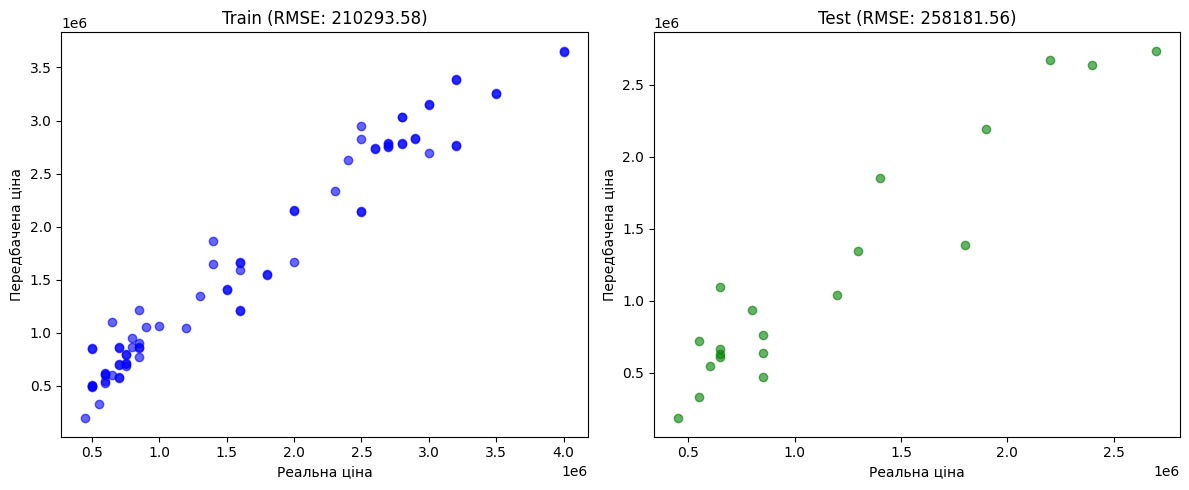

In [74]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_train, y_train_pred, color='blue', alpha=0.6)
plt.title(f'Train (RMSE: {rmse_train:.2f})')
plt.xlabel('Реальна ціна')
plt.ylabel('Передбачена ціна')

plt.subplot(1, 2, 2)
plt.scatter(y_test, y_test_pred, color='green', alpha=0.6)
plt.title(f'Test (RMSE: {rmse_test:.2f})')
plt.xlabel('Реальна ціна')
plt.ylabel('Передбачена ціна')

plt.tight_layout()
plt.show()

Якщо реальна ціна зростае, то передбачена теж зростае. Різниця між RMSE на тренувальних і тестових даних невелика. Модель досить якісна.

**Завдання 7**. Ми хочемо проаналізувати як впливає кожен чинник на цілову змінну. Для цього давайте промасштабуємо наші дані.
1. Зробіть масштабування незалежних змінних використовуючи `StandardScaler`. Тренуємо на тренувальних даних, а на тестувальних лише викликаємо `transform`.

2. Натренуйте модель на відмасштабованих даних і перегляньте коефіцієнти моделі. Які колонки є найвпливовішими на формування передбачення з точки зору коефіцієнтів? Проаналізуйте напрям дії найважливіших коефіцієнтів. Чи це логічно з точки зору значення відповідних змінних, що вони впливають на цільову змінну саме в напрямі збільшення / зменшення?

In [78]:
std_scaled = StandardScaler()

In [79]:
X_train_numeric_std = std_scaled.fit_transform(X_train_numeric)
X_test_numeric_std = std_scaled.fit_transform(X_test_numeric)

In [80]:
X_train_scaled_df = pd.DataFrame(X_train_numeric_std, columns=X_train_numeric.columns, index=X_train_numeric.index)
X_test_scaled_df = pd.DataFrame(X_test_numeric_std, columns=X_test_numeric.columns, index=X_test_numeric.index)

In [81]:
model_scaled = LinearRegression()
model_scaled.fit(X_train_scaled_df, y_train)

LinearRegression()

In [87]:
model_scaled.coef_, model_scaled.intercept_

(array([   5608.68542149,   -8765.64571392,  -94398.72148597,
        -131715.51202972,  -21377.45333789,  496769.21489874,
          -2148.92454899, -183848.01890892,  116693.76820576,
          42344.95281544,  205600.14776875,  208407.31378257,
        -118209.45031066,  -62753.005386  , -152304.86391146,
        -140945.16290405, -112259.96701985,  210048.78114763,
         -65996.24697212,   15805.70151142,  -92968.2600652 ]),
 np.float64(1680000.0000000002))

In [86]:
coef_model = pd.DataFrame({
    'Назва колонки': np.append(X_train_scaled_df.columns, 1),
    'Коефіцієнт': np.append(model_scaled.coef_, model_scaled.intercept_)
})

coef_model = coef_model.sort_values(by='Коефіцієнт', ascending=False)

coef_model

,Назва колонки,Коефіцієнт
21,1,1.680000e+06
5,Power,4.967692e+05
17,Brand_Mercedes,2.100488e+05
11,Brand_BMW,2.084073e+05
10,Brand_Audi,2.056001e+05
8,Transmission_Code,1.166938e+05
9,Owner_Type_Codes,4.234495e+04
19,Brand_Toyota,1.580570e+04
0,Car_ID,5.608685e+03
6,Seats,-2.148925e+03


Power	(496769) - Коефіцієнт позитивний, чим вище потужність двигуна, тим дорожчий автомобіль.  
Kilometers_Driven (-94398) - Коефіцієнт негативний, ціна стає меншою   
1680000 це "базова" вартість машини, від якої регресія відштовхується  

Модель поводиться логічно. Найважливішим фактором для прогнозування ціни виявилася потужність (Power), на другому місці – престижність бренду (Mercedes, BMW, Audi). А фактори часу (Year) та пробіг (Kilometers_Driven) тягнуть ціну вниз.

**Завдання 8.** На тих самих відмасштабованих даних натренуйте модель з `statsmodels`. Виведіть звіт і проаналізуйте p-value коефіцієнтів. Які ознаки є стат значущими на рівні значущості 0.05? Напишіть їх список.

In [89]:
Y = y_train
X = X_train_scaled_df

X = sm.add_constant(X)
model = sm.OLS(Y, X)
results = model.fit()

print(results.params)
print(results.summary())

const                1.680000e+06
Car_ID               5.608685e+03
Year                -8.765646e+03
Kilometers_Driven   -9.439872e+04
Mileage             -1.317155e+05
Engine              -2.137745e+04
Power                4.967692e+05
Seats               -2.148925e+03
Fuel_Type_Code      -1.838480e+05
Transmission_Code    1.166938e+05
Owner_Type_Codes     4.234495e+04
Brand_Audi           2.056001e+05
Brand_BMW            2.084073e+05
Brand_Ford          -1.182095e+05
Brand_Honda         -6.275301e+04
Brand_Hyundai       -1.523049e+05
Brand_Mahindra      -1.409452e+05
Brand_Maruti        -1.122600e+05
Brand_Mercedes       2.100488e+05
Brand_Tata          -6.599625e+04
Brand_Toyota         1.580570e+04
Brand_Volkswagen    -9.296826e+04
dtype: float64
                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.959
Model:                            OLS   Adj. R-squared:                  0.945


Ознаки, які є стат значущими на рівні значущості 0.05:  
- const  
- Mileage  
- Power  
- Fuel_Type_Code  
- Transmission_Code  
- Brand_Audi  
- Brand_BMW  
- Brand_Ford  
- Brand_Hyundai  
- Brand_Mahindra  
- Brand_Maruti  
- Brand_Mercedes
- Brand_Volkswagen

**Завдання 9**. Натренуйте лінійну регресію з `statsmodels` тільки на ознаках, які виявлись стат. значущими в попередньому завданні. Проаналізуйте показники моделі. Чи значно змінились R2 і Adj. R-squared?

In [90]:
significant_features = [
    'Mileage', 'Power', 'Fuel_Type_Code', 'Transmission_Code',
    'Brand_Audi', 'Brand_BMW', 'Brand_Ford', 'Brand_Hyundai',
    'Brand_Mahindra', 'Brand_Maruti', 'Brand_Mercedes', 'Brand_Volkswagen'
]

X_train_significant = X_train_scaled_df[significant_features]

Y = y_train
X_sig = sm.add_constant(X_train_significant)

model_sig = sm.OLS(Y, X_sig)
results_sig = model_sig.fit()

print(results_sig.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.951
Model:                            OLS   Adj. R-squared:                  0.943
Method:                 Least Squares   F-statistic:                     109.4
Date:                Sun, 21 Jun 2026   Prob (F-statistic):           4.12e-39
Time:                        21:33:35   Log-Likelihood:                -1100.4
No. Observations:                  80   AIC:                             2227.
Df Residuals:                      67   BIC:                             2258.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const               1.68e+06   2.78e+0

Було:  
R-squared: 0.959  
Adj. R-squared: 0.945  

Стало:  
R-squared: 0.951  
Adj. R-squared: 0.943  

Це свідчить про те, що видалені ознаки дійсно не були статистично значущими.

**Завдання 10**. Натренуйте лінійну регресію з `statsmodels` на усіх ознаках з масштабованого `X_train`, у яких p_value в завданні 8 менше за `0.25`. Ми таким чином помʼякшили критерій відбору ознак. Проаналізуйте показники моделі. Чи значно змінились R2 і Adj. R-squared порівняно з завданням 8? Яку модель з останніх 3х завдань ви б лишили для використання?

In [92]:
features_025 = [
    'Mileage', 'Power', 'Fuel_Type_Code', 'Transmission_Code',
    'Brand_Audi', 'Brand_BMW', 'Brand_Ford', 'Brand_Hyundai',
    'Brand_Mahindra', 'Brand_Maruti', 'Brand_Mercedes', 'Brand_Volkswagen',
    'Kilometers_Driven', 'Brand_Honda', 'Brand_Tata'
]

X_train_025 = X_train_scaled_df[features_025]

Y = y_train
X_opt = sm.add_constant(X_train_025)

model_025 = sm.OLS(Y, X_opt)
results_025 = model_025.fit()

print(results_025.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.958
Model:                            OLS   Adj. R-squared:                  0.948
Method:                 Least Squares   F-statistic:                     97.03
Date:                Sun, 21 Jun 2026   Prob (F-statistic):           4.85e-38
Time:                        21:37:58   Log-Likelihood:                -1094.7
No. Observations:                  80   AIC:                             2221.
Df Residuals:                      64   BIC:                             2260.
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const               1.68e+06   2.65e+0

R-squared: 0.958  
Adj. R-squared: 0.948  
показники моделі практично не змінилися, тому залишаємо останню модель, тому що вона використовує більше ознак.  